## Оценка метрик и качества

══════════════════════════════════════════════════
Сравнение моделей по метрикам качества:
══════════════════════════════════════════════════
           Model           R2  MAPE_percent
        CatBoost     0.959589     21.205181
    RandomForest     0.954698     21.405655
        LightGBM     0.951962     22.985357
LinearRegression -7885.006498  10340.267340

══════════════════════════════════════════════════


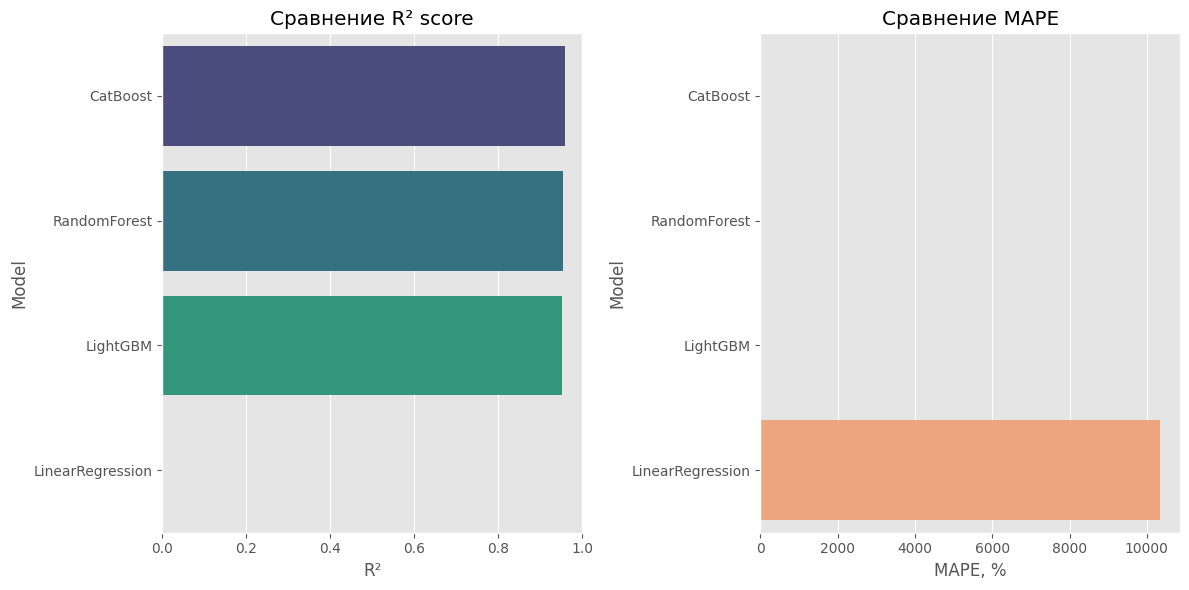


Лучшая модель: CatBoost
- R²: 0.9596
- Ошибка (MAPE): 21.21%


In [ ]:
# Вычисление метрик для всех моделей
metrics = {
    'Model': ['LinearRegression', 'RandomForest', 'CatBoost', 'LightGBM'],
    'R2': [
        r2_score(y_test, lr_preds),
        r2_score(y_test, rf_preds),
        r2_score(y_test, cat_preds),
        r2_score(y_test, lgb_preds)
    ],
    'MAPE': [
        mean_absolute_percentage_error(y_test, lr_preds),
        mean_absolute_percentage_error(y_test, rf_preds),
        mean_absolute_percentage_error(y_test, cat_preds),
        mean_absolute_percentage_error(y_test, lgb_preds)
    ]
}

# Создаем DataFrame для удобного анализа
metrics_df = pd.DataFrame(metrics)
metrics_df['MAPE_percent'] = metrics_df['MAPE'] * 100  # MAPE в процентах

# Сортировка по R2 (от лучшего к худшему)
metrics_df = metrics_df.sort_values('R2', ascending=False)

# Вывод таблицы с метриками
print("═"*50)
print("Сравнение моделей по метрикам качества:")
print("═"*50)
print(metrics_df[['Model', 'R2', 'MAPE_percent']].to_string(index=False))
print("\n" + "═"*50)

# Визуализация результатов
plt.figure(figsize=(12, 6))

# График R2
plt.subplot(1, 2, 1)
sns.barplot(x='R2', y='Model', data=metrics_df, palette='viridis')
plt.title('Сравнение R² score')
plt.xlabel('R²')
plt.xlim(0, 1)

# График MAPE
plt.subplot(1, 2, 2)
sns.barplot(x='MAPE_percent', y='Model', data=metrics_df, palette='magma')
plt.title('Сравнение MAPE')
plt.xlabel('MAPE, %')

plt.tight_layout()
plt.show()

# Анализ лучшей модели
best_model = metrics_df.iloc[0]
print(f"\nЛучшая модель: {best_model['Model']}")
print(f"- R²: {best_model['R2']:.4f}")
print(f"- Ошибка (MAPE): {best_model['MAPE_percent']:.2f}%")